# Home Depot out-of-lane Top-1 bakeoff

**Question.** On a corpus the router never trained on (Home Depot product search — 124K
products, 11,795 queries, out-of-lane), can our cheap deployed encoder-router match the
production auto-fusion **LLM** classifier at **Top-1**, at ~zero per-query cost, and how do both
compare to fixed hybrid RRF and to a per-collection constant?

**Hypothesis.** Efficiency at equal Top-1: `our_router hit@1 ≈ auto_fusion hit@1` while our
router costs ~0 and auto-fusion costs one LLM call/query. Top-1 is the regime where routing to a
decisive single mode can beat RRF (which dilutes a clean rank-1).

**Arms** (all share the same index + RRF; only the routing decision differs): `our_router`
(whatever arm the local service has loaded), `design_branches` (a second saved arm through the
same endpoint), `balanced/no_corpus` (the 45/45/10-balanced MLP, loaded locally), `zipf_rule`
(model-free term-rarity rule), `auto_fusion` (localhost LLM, bucketed 2/6), `weighted_rrf`
(router probabilities as fusion weights), `fixed_rrf`, `dense_only`, `sparse_only`, and `oracle`
(per-query best route — the ceiling).

**Metrics.** `hit@1` (rank-1 product rated ≥ 2.0), graded `relevance@1` (grade of rank-1, else
0), `ndcg@10`, route mix, and a retrieval-cost proxy. §5d–§5g plot all four.

**Caveats (read the numbers with these).**
- *Incomplete qrels*: only ~44% of the catalog is rated, so full-corpus `hit@1` undercounts (a
  good but unrated product at #1 scores a miss). Rated-candidate re-ranking is the clean-signal
  companion (see the final section).
- `hit@1 ≥ 2.0` is lenient here (84% of rated pairs qualify) — `relevance@1` is the
  discriminating metric.
- The router embeds queries with **bge-small** to decide a route; the corpus retrieves dense with
  **all-MiniLM** (bge has no cloud endpoint). Different spaces, different jobs.
- Every model arm is served at the same `HEDGE_DELTA`. Until that was uniform, a locally-loaded
  arm at 0.07 and a served arm at the service default 0.15 differed by the hedge, not the model.
- `auto_fusion` is scored on its cached 3,000 queries; paired tests restrict to the queries both
  arms decided, so read `n` per comparison.

You run this top-to-bottom; it surfaces each stage and caches decisions so re-runs are cheap.


## 1 · Setup — cloud client, configs, data

In [1]:
from __future__ import annotations

import os

import numpy as np
import pandas as pd
import requests
from dotenv import find_dotenv, load_dotenv
from qdrant_client import QdrantClient
from tqdm.auto import tqdm

from encoder_router.table import ZipfStats
from hybrid_search_rrf_dataset.fusion import (
    DenseOnlyStrategy,
    PureRRFStrategy,
    SparseOnlyStrategy,
)
from hybrid_search_rrf_dataset.retrieval.wave3 import HOME_DEPOT_DIR, HomeDepotLane
from scripts.index_home_depot import DENSE, SPARSE  # exact cfgs the corpus was indexed with

COLLECTION = "home-depot"
# ROUTER_URL = os.environ.get("ROUTER_URL", "http://localhost:8000/classify/pure")  # local serve.py
ROUTER_URL = 'http://127.0.0.1:8001/classify/pure'
REL_THRESHOLD = 2.0          # a rank-1 product counts as a hit at this grade or above
FETCH_LIMIT = 20             # polite top-k for cloud retrieval
HEDGE_DELTA = 0.07           # |p_dense - p_sparse| under this -> pure_rrf, for EVERY arm:
                             # the service default is 0.15, so a served arm compared against a
                             # locally-loaded one at 0.07 differs by the hedge, not the model
SAMPLE_SIZE = None
SEED = 0
CACHE = HOME_DEPOT_DIR       # sample + decision caches live beside the CSVs

load_dotenv(find_dotenv(usecwd=True))   # QDRANT_* from the project-root .env — no shell export needed
url = os.environ.get("QDRANT_CLOUD_URL")
api_key = os.environ.get("QDRANT_CLOUD_API_KEY")
assert url and api_key, "set $QDRANT_URL/$QDRANT_CLOUD_URL and $QDRANT_API_KEY"
client = QdrantClient(url=url, api_key=api_key, cloud_inference=True, timeout=120)
assert client.collection_exists(COLLECTION), f"index the corpus first — '{COLLECTION}' missing"

lane = HomeDepotLane()
lane.load_metadata()
queries = lane.queries().set_index("query_id")   # query_id -> text
qrels = lane.qrels()                              # query_id, doc_id, relevance (float 1-3)
print(f"{len(queries):,} queries | {len(qrels):,} qrels | corpus collection '{COLLECTION}'")


11,795 queries | 74,067 qrels | corpus collection 'home-depot'


## 2 · Query set — the full lane, or a stratified sample for iteration

`SAMPLE_SIZE = None` scores the **whole lane** (11,795 queries): the reporting mode, and the only
one with no sampling caveat to defend. Set an integer for fast iteration when adding an arm — it
draws a sample stratified on query term-rarity (`ZipfStats.rare_share`) rather than uniformly,
cached so every arm scores the identical set.

Develop on the sample, publish the full lane: the 3,000-query sample ran ~0.03 optimistic on
every absolute number (sparse constant 0.646 vs 0.616, oracle 0.858 vs 0.845) and mis-ranked
`zipf_rule` by four places. The sample file also gives you a free split — tune on those 3,000,
report on the 8,795 complement.


In [2]:
SAMPLE_PATH = CACHE / "sample_query_ids.parquet"
FORCE_UPDATE = True

if SAMPLE_SIZE is None:                  # whole lane — no stratification, and nothing worth caching
    sample_ids = queries.index.astype(str).tolist()
    print(f"full query set: {len(sample_ids):,} queries")
elif SAMPLE_PATH.exists() and not FORCE_UPDATE:
    sample_ids = pd.read_parquet(SAMPLE_PATH)["query_id"].astype(str).tolist()
    print(f"reloaded {len(sample_ids):,} sampled query ids")
else:
    q = queries.reset_index()
    q["rare_share"] = ZipfStats().frame(queries["text"])["zipf.rare_share"].to_numpy()
    q["bin"] = pd.cut(q["rare_share"], [-0.01, 0.15, 0.5, 1.01],
                      labels=["semantic", "mixed", "lexical"])
    take = min(SAMPLE_SIZE, len(q))
    frac = take / len(q)
    # explicit per-bin loop (groupby.apply drops the group column in pandas >=2.2)
    parts = [
        g.sample(min(len(g), max(1, round(len(g) * frac))), random_state=SEED)
        for _, g in q.groupby("bin", observed=True)
    ]
    sample = pd.concat(parts).sample(frac=1, random_state=SEED).head(take).reset_index(drop=True)
    sample_ids = sample["query_id"].astype(str).tolist()
    pd.DataFrame({"query_id": sample_ids}).to_parquet(SAMPLE_PATH, index=False)
    print(sample["bin"].value_counts().to_string())
    print(f"sampled {len(sample_ids):,} queries -> {SAMPLE_PATH}")

sample_text = {qid: queries.loc[qid, "text"] for qid in sample_ids}


full query set: 11,795 queries


## 3 · Collect routing decisions (cached; collect once)

In [3]:
# hit the FULL /classify (returns p_dense/p_sparse per query) — routes for our_router AND
# the fusion weights for weighted_rrf. Cheap: no LLM, just the embedding+MLP head.
CLASSIFY_URL = ROUTER_URL.replace("/classify/pure", "/classify")
PROBS_PATH = CACHE / "router_probs.parquet"

FORCE_CELL = True

if PROBS_PATH.exists() and not FORCE_CELL:
    rp = pd.read_parquet(PROBS_PATH).astype({"query_id": str})
    print(f"reloaded {len(rp):,} router probabilities")
else:
    rows = []
    for i in tqdm(range(0, len(sample_ids), 64), desc="router /classify"):
        chunk = sample_ids[i:i + 64]
        resp = requests.post(CLASSIFY_URL, json={"queries": [sample_text[q] for q in chunk],
                                                  "delta": HEDGE_DELTA}, timeout=60)
        resp.raise_for_status()
        for qid, r in zip(chunk, resp.json()["results"]):
            rows.append({"query_id": qid, "route": r["route"],
                         "p_dense": r["p_dense"], "p_sparse": r["p_sparse"]})
    rp = pd.DataFrame(rows)
    rp.to_parquet(PROBS_PATH, index=False)
    print(f"collected {len(rp):,} router decisions -> {PROBS_PATH}")

router_routes = rp.set_index("query_id")["route"].to_dict()
p_dense = rp.set_index("query_id")["p_dense"].to_dict()
p_sparse = rp.set_index("query_id")["p_sparse"].to_dict()
print("our_router mix:", pd.Series(router_routes).value_counts(normalize=True).round(2).to_dict())


router /classify:   0%|          | 0/185 [00:00<?, ?it/s]

collected 11,795 router decisions -> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/router_probs.parquet
our_router mix: {'sparse_only': 0.64, 'pure_rrf': 0.25, 'dense_only': 0.11}


In [4]:
# auto-fusion: call the live classifier (default local 0.0.0.0:8082), cache scores once.
# A key is needed ONLY if the service runs with SERVICE_API_KEYS set — sent only when present.
AUTOFUSION_URL = os.environ.get("AUTOFUSION_URL", "http://0.0.0.0:8082/v1/classify")
AUTOFUSION_KEY = os.environ.get("AUTOFUSION_KEY") or os.environ.get("QDRANT_LLM_FUSION_KEY", "")
AF_PATH = CACHE / "autofusion_scores.parquet"
DENSE_MAX, HYBRID_MAX = 2, 6   # production buckets: 0-2 dense, 3-6 rrf, >6 sparse


def bucket(score: float) -> str:
    s = int(round(score))
    if s <= DENSE_MAX:
        return "dense_only"
    if s <= HYBRID_MAX:
        return "pure_rrf"
    return "sparse_only"


headers = {"Content-Type": "application/json"}
if AUTOFUSION_KEY:                       # omit the header entirely for an open (no-auth) service
    headers["Authorization"] = f"Bearer {AUTOFUSION_KEY}"

if AF_PATH.exists():
    af = pd.read_parquet(AF_PATH).astype({"query_id": str}).set_index("query_id")["score"]
    print(f"reloaded {len(af):,} auto-fusion scores")
else:
    try:
        rows = []
        for qid in tqdm(sample_ids, desc="auto-fusion /v1/classify"):   # 1 LLM call/query
            resp = requests.post(AUTOFUSION_URL, json={"text": sample_text[qid]}, headers=headers, timeout=45)
            resp.raise_for_status()
            body = resp.json()
            rows.append({"query_id": qid, "score": body["score"], "expected_score": body["expected_score"]})
        pd.DataFrame(rows).to_parquet(AF_PATH, index=False)
        af = pd.DataFrame(rows).astype({"query_id": str}).set_index("query_id")["score"]
        print(f"collected {len(af):,} auto-fusion scores -> {AF_PATH}")
    except requests.RequestException as exc:
        af = None
        print(f"auto_fusion SKIPPED — {AUTOFUSION_URL} unreachable/rejected ({exc}). "
              "Start the service, or set AUTOFUSION_KEY if it enforces SERVICE_API_KEYS.")

autofusion_routes = None if af is None else {q: bucket(af[q]) for q in sample_ids if q in af.index}
if autofusion_routes:
    print("auto_fusion mix:", pd.Series(autofusion_routes).value_counts(normalize=True).round(2).to_dict())


reloaded 3,000 auto-fusion scores
auto_fusion mix: {'pure_rrf': 0.92, 'dense_only': 0.06, 'sparse_only': 0.02}


## 4 · Retrieve rank-1 and score (full-corpus)

Every arm queries the same index; the arm only chooses which `FusionStrategy` runs.
`rank()` returns `{doc_id: score}` score-sorted, so rank-1 is the first key.

In [5]:
from concurrent.futures import ThreadPoolExecutor

strategies = {
    "dense_only": DenseOnlyStrategy(client, COLLECTION, DENSE, SPARSE, fetch_limit=FETCH_LIMIT),
    "sparse_only": SparseOnlyStrategy(client, COLLECTION, DENSE, SPARSE, fetch_limit=FETCH_LIMIT),
    "pure_rrf": PureRRFStrategy(client, COLLECTION, DENSE, SPARSE, fetch_limit=FETCH_LIMIT),
}
rated = {qid: dict(zip(g["doc_id"].astype(str), g["relevance"]))
         for qid, g in qrels.astype({"query_id": str}).groupby("query_id")}

# Retrieve the FULL top-k ONCE per (query, strategy), in parallel, and cache it. rank-1
# (for hit@1/relevance@1) and the top-10 (for ndcg@10) both come from this one cache.
RANKINGS_PATH = CACHE / "rankings_by_strategy.parquet"
MAX_WORKERS = 16


def _ranking(task: tuple[str, str]) -> tuple[str, str, list[str]]:
    qid, route = task
    return qid, route, list(strategies[route].rank(sample_text[qid]))   # doc_ids, score-sorted


rankings: dict[str, dict[str, list[str]]] = {qid: {} for qid in sample_ids}
cached = None
if RANKINGS_PATH.exists():
    cached = pd.read_parquet(RANKINGS_PATH).astype({"query_id": str, "route": str, "doc_id": str})
    for (qid, route), g in cached.sort_values("rank").groupby(["query_id", "route"]):
        if qid in rankings:
            rankings[qid][route] = g["doc_id"].tolist()
    print(f"reloaded {sum(map(len, rankings.values())):,} cached (query, route) pairs")

# Retrieve only the pairs the cache is missing. The cache is keyed by query_id, so growing
# the query set tops it up; the old all-or-nothing reload scored uncovered queries as misses.
tasks = [(qid, route) for qid in sample_ids for route in strategies if route not in rankings[qid]]
if tasks:
    for strat in strategies.values():           # single-threaded warmup: init local bm25
        strat.rank(sample_text[sample_ids[0]])  # before threads race on its lazy init
    fresh = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        for qid, route, docs in tqdm(pool.map(_ranking, tasks), total=len(tasks), desc="retrieve top-k"):
            rankings[qid][route] = docs
            fresh += [{"query_id": qid, "route": route, "rank": i, "doc_id": d}
                      for i, d in enumerate(docs)]
    frames = [f for f in (cached, pd.DataFrame(fresh)) if f is not None and len(f)]
    pd.concat(frames, ignore_index=True).to_parquet(RANKINGS_PATH, index=False)
    print(f"retrieved {len(tasks):,} new (query, route) pairs -> {RANKINGS_PATH}")
else:
    print("cache already covers every (query, route) pair")


def top1(qid: str, route: str) -> str | None:
    docs = rankings[qid].get(route) or []
    return docs[0] if docs else None


def score_arm(route_of) -> pd.DataFrame:
    rows = []
    for qid in sample_ids:
        route = route_of(qid)
        if route is None:
            continue
        doc = top1(qid, route)
        grade = rated.get(qid, {}).get(doc, 0.0) if doc is not None else 0.0
        rows.append({"query_id": qid, "route": route, "top1": doc,
                     "hit": grade >= REL_THRESHOLD,
                     "rel_at_1": grade if grade >= REL_THRESHOLD else 0.0})
    return pd.DataFrame(rows)


reloaded 35,218 cached (query, route) pairs


retrieve top-k:   0%|          | 0/167 [00:00<?, ?it/s]

retrieved 167 new (query, route) pairs -> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/rankings_by_strategy.parquet


In [6]:
# weighted RRF: fuse dense+sparse using the router's p_dense/p_sparse as per-query fusion
# weights (the repo's original "learned fusion weight" idea). Reuses the cached rankings.
RRF_K = 60


def _weighted_rrf(qid: str) -> list[str]:
    wd, ws = p_dense.get(qid, 0.5), p_sparse.get(qid, 0.5)
    score: dict[str, float] = {}
    for r, d in enumerate(rankings[qid].get("dense_only") or []):
        score[d] = score.get(d, 0.0) + wd / (RRF_K + r + 1)
    for r, d in enumerate(rankings[qid].get("sparse_only") or []):
        score[d] = score.get(d, 0.0) + ws / (RRF_K + r + 1)
    return [d for d, _ in sorted(score.items(), key=lambda kv: kv[1], reverse=True)]


for _q in sample_ids:
    rankings[_q]["weighted_rrf"] = _weighted_rrf(_q)

arms = {
    "our_router": lambda q: router_routes.get(q),
    "weighted_rrf": lambda q: "weighted_rrf",
    "fixed_rrf": lambda q: "pure_rrf",
    "dense_only": lambda q: "dense_only",
    "sparse_only": lambda q: "sparse_only",
}
if autofusion_routes is not None:
    arms["auto_fusion"] = lambda q: autofusion_routes.get(q)

results = {name: score_arm(fn) for name, fn in arms.items()}


### 4b · Local query-only routers — balanced MLP + pure Zipf rule

Two serve-safe, query-only routers added as arms next to the volume-trained `our_router`:
`balanced/no_corpus` (the 45/45/10-balanced MLP from `models/os_distill_relabel_balanced/`)
and `zipf_rule` (rare→sparse / common→dense, no model). Both route from the query text alone,
so they need no live service — classified locally over the same sample, scored on the same rankings.


In [7]:
# 4b — load the balanced MLP + the Zipf rule locally, classify the sample, register both as arms
import json as _json, joblib
from pathlib import Path as _P
from sentence_transformers import SentenceTransformer
from encoder_router.table import (MODELS_DIR, LexicalShape, NgramSvd, ZipfStats,
                                   serve_from_probabilities)
from encoder_router.model import EncoderRouter
from encoder_router.training import QueryEmbeddings

BASE_BAL  = MODELS_DIR / "os_distill_relabel_balanced"
RRF_DELTA = HEDGE_DELTA                       # near-tie hedge to pure_rrf (same as the probe)

def load_classifier(arm_dir, delta=RRF_DELTA):
    """Reload a serve-safe saved arm into classify(queries)->DataFrame(query, route). Rebuilds the
    exact training input stack ([bge; aux?; svd; zipf?; shape?]) and serves via tuned thresholds + hedge."""
    p = _P(arm_dir); meta = _json.loads((p / "meta.json").read_text())
    if not meta["serve_safe"]:
        raise RuntimeError(f"{meta['arm']} needs taxonomy features at inference — not serve-safe")
    svd = NgramSvd.load(p / "svd.joblib"); thr = np.load(p / "thresholds.npy")
    st = SentenceTransformer(meta["embedding_model"]); prefix = meta["prefix"]; aux = meta.get("aux_embedding_model")
    er = EncoderRouter.load(p / "router.pt")
    zst = (np.load(p / "zipf_mean.npy"), np.load(p / "zipf_std.npy")) if meta["zipf_inputs"] else None
    sst = (np.load(p / "shape_mean.npy"), np.load(p / "shape_std.npy")) if meta.get("shape_inputs") else None
    def classify(queries):
        q = [queries] if isinstance(queries, str) else list(queries)
        emb = np.asarray(st.encode([prefix + t for t in q], normalize_embeddings=True))
        if aux:
            emb = np.concatenate([emb, QueryEmbeddings(aux)._encode(q, 100)], axis=1)
        blocks = [emb, svd.transform(pd.Series(q))]
        if zst is not None:
            blocks.append((ZipfStats().frame(pd.Series(q)).to_numpy(np.float32) - zst[0]) / zst[1])
        if sst is not None:
            blocks.append((LexicalShape().frame(pd.Series(q)).to_numpy(np.float32) - sst[0]) / sst[1])
        probs = er.probabilities(np.concatenate(blocks, axis=1).astype(np.float32))
        base = np.asarray(serve_from_probabilities(probs, thr))
        d = probs["dense_only"].to_numpy(); s = probs["sparse_only"].to_numpy()
        return pd.DataFrame({"query": q, "route": np.where(np.abs(d - s) < delta, "pure_rrf", base)})
    return classify

Z_RARE_SHARE, Z_OOV_SHARE, Z_COMMON_MEAN, Z_BASE = 0.30, 0.20, 4.50, "sparse_only"
def zipf_router(queries):
    """Pure rule (probe §4f): >=30% rare or >=20% OOV tokens -> sparse; mean zipf>=4.5 -> dense; else base."""
    q = [queries] if isinstance(queries, str) else list(queries)
    zf = ZipfStats().frame(pd.Series(q))
    rs, ov, mn = zf["zipf.rare_share"].to_numpy(), zf["zipf.oov_share"].to_numpy(), zf["zipf.mean"].to_numpy()
    route = np.full(len(q), Z_BASE, dtype=object)
    route = np.where(mn >= Z_COMMON_MEAN, "dense_only", route)
    route = np.where((rs >= Z_RARE_SHARE) | (ov >= Z_OOV_SHARE), "sparse_only", route)
    return pd.DataFrame({"query": q, "route": route})

_texts = [sample_text[q] for q in sample_ids]

# balanced arm: from the DEPLOYED service once it is in the served library, else load locally.
# To deploy: cp -r models/os_distill_relabel_balanced/no_branches models/classifiers_union_200k/<arm>,
# start a service with ROUTER_DIR=<that dir> (or /reload to it in dev), then set BALANCED_ROUTER_URL.
BALANCED_ROUTER_URL = os.environ.get("BALANCED_ROUTER_URL")   # e.g. http://127.0.0.1:8003/classify
if BALANCED_ROUTER_URL:
    _pairs = []
    for i in tqdm(range(0, len(sample_ids), 64), desc="balanced /classify"):
        chunk = sample_ids[i:i + 64]
        resp = requests.post(BALANCED_ROUTER_URL, json={"queries": [sample_text[q] for q in chunk]}, timeout=60)
        resp.raise_for_status()
        _pairs += [(q, r["route"]) for q, r in zip(chunk, resp.json()["results"])]
    balanced_routes = dict(_pairs)
    print(f"balanced/no_corpus: {len(balanced_routes):,} routes from {BALANCED_ROUTER_URL}")
else:
    bal_classify    = load_classifier(BASE_BAL / "no_branches")   # swap for any serve-safe balanced arm
    balanced_routes = dict(zip(sample_ids, bal_classify(_texts)["route"]))
    print("balanced/no_corpus: routed LOCALLY (set BALANCED_ROUTER_URL to use the deployed service)")

zipf_routes = dict(zip(sample_ids, zipf_router(_texts)["route"]))

# balanced/zipf_shape: the balanced arm with zipf + lexical-shape stats added to the input —
# same 45/45/10-trained family as balanced/no_corpus, different feature set
bal_zs_classify   = load_classifier(BASE_BAL / "zipf_shape_nocorpus")
balanced_zs_routes = dict(zip(sample_ids, bal_zs_classify(_texts)["route"]))
arms["balanced/zipf_shape"] = lambda q: balanced_zs_routes.get(q)
results["balanced/zipf_shape"] = score_arm(arms["balanced/zipf_shape"])
print("balanced/zipf_shape mix:",
      pd.Series(balanced_zs_routes).value_counts(normalize=True).round(2).to_dict())

# design_branches through the DEPLOYED service: /reload onto it, classify the sample, put the
# service back on the arm it was serving. Same code path as our_router, so the two rows differ
# only by arm — and the hedge is the service's own, not a notebook constant.
DESIGN_ARM  = "design_branches"
ROUTER_BASE = CLASSIFY_URL.rsplit("/classify", 1)[0]


def routes_from_service(arm: str) -> dict[str, str]:
    """Route the sample on `arm` via the live service, restoring the previous arm afterwards."""
    was = requests.get(f"{ROUTER_BASE}/health", timeout=15).json()
    requests.post(f"{ROUTER_BASE}/reload", json={"arm": arm}, timeout=180).raise_for_status()
    try:
        live = requests.get(f"{ROUTER_BASE}/health", timeout=15).json()
        print(f"{arm}: serving live | delta={HEDGE_DELTA} (service default {live['rrf_delta']}) "
              f"trained={live['trained_at']}")
        out = {}
        for i in tqdm(range(0, len(sample_ids), 64), desc=f"{arm} /classify"):
            chunk = sample_ids[i:i + 64]
            resp = requests.post(CLASSIFY_URL, json={"queries": [sample_text[q] for q in chunk],
                                                      "delta": HEDGE_DELTA}, timeout=60)
            resp.raise_for_status()
            out.update({q: r["route"] for q, r in zip(chunk, resp.json()["results"])})
        return out
    finally:
        requests.post(f"{ROUTER_BASE}/reload", json={"arm": was["arm"]}, timeout=180)
        print(f"service restored to {was['arm']}")


design_routes = routes_from_service(DESIGN_ARM)

arms["balanced/no_corpus"] = lambda q: balanced_routes.get(q)
arms["zipf_rule"]          = lambda q: zipf_routes.get(q)
arms["design_branches"]    = lambda q: design_routes.get(q)
for _name, _routes in (("balanced/no_corpus", balanced_routes), ("zipf_rule", zipf_routes),
                       ("design_branches", design_routes)):
    results[_name] = score_arm(arms[_name])
    print(f"{_name} mix:", pd.Series(_routes).value_counts(normalize=True).round(2).to_dict())


balanced/no_corpus: routed LOCALLY (set BALANCED_ROUTER_URL to use the deployed service)


balanced/zipf_shape mix: {'sparse_only': 0.78, 'pure_rrf': 0.14, 'dense_only': 0.08}


design_branches: serving live | delta=0.07 (service default 0.15) trained=2026-09-10 09:56:45


design_branches /classify:   0%|          | 0/185 [00:00<?, ?it/s]

service restored to zipf_shape_nocorpus
balanced/no_corpus mix: {'sparse_only': 0.74, 'pure_rrf': 0.23, 'dense_only': 0.03}
zipf_rule mix: {'sparse_only': 0.73, 'dense_only': 0.27}
design_branches mix: {'sparse_only': 0.71, 'dense_only': 0.16, 'pure_rrf': 0.13}


### Oracle ceiling

The best achievable Top-1 if you always picked the right route per query. Now a **free
lookup** over the precomputed rank-1s — no extra cloud calls, so it always runs.

In [8]:
BASE_ROUTES = ("dense_only", "sparse_only", "pure_rrf")   # oracle picks among the discrete routes


def oracle_row(qid: str) -> dict:
    best = {"query_id": qid, "route": None, "top1": None, "hit": False, "rel_at_1": 0.0}
    for route in BASE_ROUTES:
        doc = top1(qid, route)
        grade = rated.get(qid, {}).get(doc, 0.0) if doc is not None else 0.0
        if grade > best["rel_at_1"]:
            best = {"query_id": qid, "route": route, "top1": doc,
                    "hit": grade >= REL_THRESHOLD, "rel_at_1": grade}
    return best


results["oracle"] = pd.DataFrame([oracle_row(q) for q in sample_ids])


## 5 · Readout

In [9]:
def summarize(name: str, df: pd.DataFrame) -> dict:
    return {"arm": name, "n": len(df),
            "hit@1": df["hit"].mean(), "relevance@1": df["rel_at_1"].mean(),
            "llm_calls/query": 1.0 if name == "auto_fusion" else 0.0}


summary = (pd.DataFrame([summarize(n, d) for n, d in results.items()])
           .sort_values("relevance@1", ascending=False).reset_index(drop=True))
display(summary.round(3))

for name in [a for a in ("our_router", "auto_fusion") if a in results]:
    print(name, "route mix:",
          results[name]["route"].value_counts(normalize=True).round(2).to_dict())


,arm,n,hit@1,relevance@1,llm_calls/query
0,oracle,11795,0.305,0.845,0.0
1,sparse_only,11795,0.233,0.616,0.0
2,balanced/no_corpus,11795,0.224,0.594,0.0
3,balanced/zipf_shape,11795,0.222,0.587,0.0
4,our_router,11795,0.220,0.585,0.0
5,design_branches,11795,0.212,0.563,0.0
6,fixed_rrf,11795,0.208,0.552,0.0
7,auto_fusion,3000,0.207,0.550,1.0
8,weighted_rrf,11795,0.204,0.544,0.0
9,zipf_rule,11795,0.204,0.540,0.0


our_router route mix: {'sparse_only': 0.64, 'pure_rrf': 0.25, 'dense_only': 0.11}
auto_fusion route mix: {'pure_rrf': 0.92, 'dense_only': 0.06, 'sparse_only': 0.02}


## 5b · NDCG@10 — does the top-1 story hold at depth?

Top-1 favours a decisive single retriever; NDCG@10 rewards relevant docs anywhere in the
top-10, which is what RRF fusion optimises. So this is the honest depth check: sparse can
win rank-1 while hybrid wins the fuller ranking. Same incomplete-qrels caveat (unrated
docs score 0 gain), so read the ordering, not the absolute value.

In [10]:
K = 10


def _idcg(qid: str) -> float:
    grades = sorted(rated.get(qid, {}).values(), reverse=True)[:K]
    ideal = sum(g / np.log2(i + 2) for i, g in enumerate(grades))
    return ideal or 1.0   # queries with no rated docs -> ndcg defined as 0 via 0 numerator


def ndcg_at_k(qid: str, route: str) -> float:
    docs = (rankings[qid].get(route) or [])[:K]
    dcg = sum(rated.get(qid, {}).get(d, 0.0) / np.log2(i + 2) for i, d in enumerate(docs))
    return dcg / _idcg(qid)


ndcg = {name: np.mean([ndcg_at_k(q, fn(q)) for q in sample_ids if fn(q) is not None])
        for name, fn in arms.items()}
ndcg["oracle"] = np.mean([max(ndcg_at_k(q, r) for r in rankings[q]) for q in sample_ids])
display(pd.DataFrame([{"arm": k, "ndcg@10": v} for k, v in ndcg.items()])
        .sort_values("ndcg@10", ascending=False).reset_index(drop=True).round(3))


,arm,ndcg@10
0,oracle,0.316
1,sparse_only,0.264
2,balanced/no_corpus,0.254
3,balanced/zipf_shape,0.252
4,our_router,0.249
5,design_branches,0.244
6,fixed_rrf,0.237
7,zipf_rule,0.234
8,auto_fusion,0.233
9,weighted_rrf,0.214


### 5d · Standings — every arm against the constant and the ceiling

`our_router` in colour, the rest as context. Two reference lines carry the whole story: the
best per-collection **constant** (which no arm beats) and the **oracle** (perfect per-query
routing). The distance to the oracle is retrieval headroom, not routing headroom.


/var/folders/pq/gsx7ryn905s1bypf32zs4k980000gn/T/ipykernel_46585/318880486.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_yticklabels([a.replace("/no_corpus", "/no_corpus\n") for a in ORDER], fontsize=9)


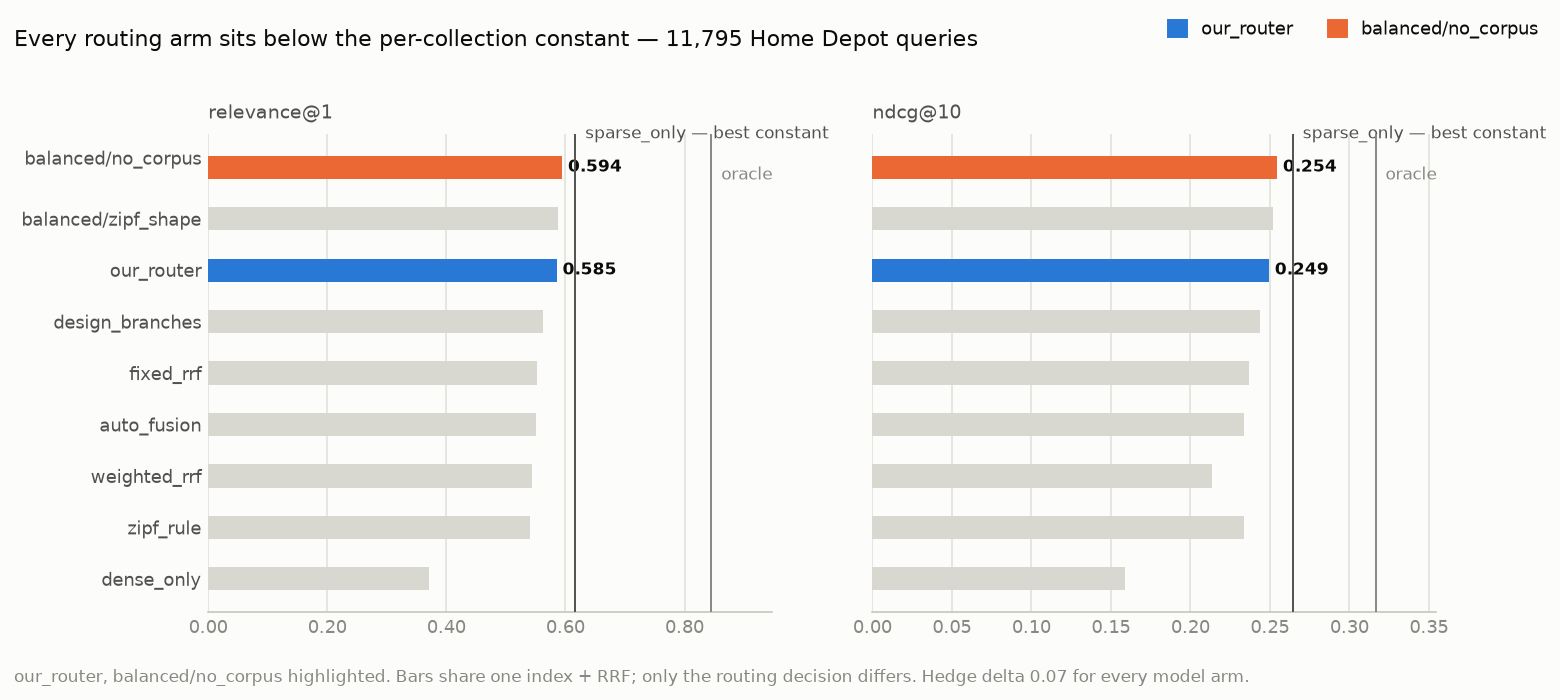

In [11]:
# 5d — chart tokens + shared axis style. One validated palette for every figure below:
# categorical blue/orange/aqua, diverging blue<->red, gray for context marks.
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, DIM = "#e1e0d9", "#c3c2b7", "#d8d7d0"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 9.5, "text.color": INK,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "figure.dpi": 140,
})


def bare(ax, xgrid=True):
    """Hairline solid grid on one axis, no box — the data is the only loud thing."""
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0)
    if xgrid:
        ax.set_axisbelow(True)
        ax.xaxis.grid(True, color=GRID, linewidth=0.8, linestyle="-")
        ax.yaxis.grid(False)


# Two subjects, both ours: the deployed classifier and the 100K-trained balanced arm.
# >=2 highlighted series -> a legend is mandatory (dataviz rule); the rest recede to gray.
SUBJECTS = [("our_router", BLUE), ("balanced/no_corpus", ORANGE)]
CONSTANT = "sparse_only"        # shown ONLY as the reference line below — its own bar would
                                 # duplicate that line, since best_const IS this arm's score
ORDER = [a for a in summary.sort_values("relevance@1")["arm"] if a not in ("oracle", CONSTANT)]
_orc = summary.set_index("arm").loc["oracle"]
_subject_color = dict(SUBJECTS)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4), sharey=True)
for ax, (metric, values, ceiling) in zip(axes, [
        ("relevance@1", summary.set_index("arm")["relevance@1"], _orc["relevance@1"]),
        ("ndcg@10", pd.Series(ndcg), ndcg["oracle"])]):
    vals = [values[a] for a in ORDER]
    colors = [_subject_color.get(a, DIM) for a in ORDER]
    ax.barh(ORDER, vals, height=0.45, color=colors, zorder=3)
    best_const = values[CONSTANT]
    ax.axvline(best_const, color=INK2, lw=1.0, zorder=4)
    ax.axvline(ceiling, color=MUTED, lw=1.0, zorder=4)
    ax.text(best_const, len(ORDER) - 0.35, f"  {CONSTANT} — best constant", color=INK2,
            fontsize=8.5, va="center")
    ax.text(ceiling, len(ORDER) - 1.15, "  oracle", color=MUTED, fontsize=8.5, va="center")
    for y, (a, v) in enumerate(zip(ORDER, vals)):     # label only the two subjects
        if a in _subject_color:
            ax.text(v + ceiling * 0.012, y, f"{v:.3f}", va="center", fontsize=8.5,
                    color=INK, fontweight="bold")
    ax.set_xlim(0, ceiling * 1.12)
    ax.set_title(metric, color=INK2, fontsize=10, loc="left", pad=8)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    bare(ax)
axes[0].set_yticklabels([a.replace("/no_corpus", "/no_corpus\n") for a in ORDER], fontsize=9)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for _, c in SUBJECTS],
           labels=[a for a, _ in SUBJECTS], loc="upper right", bbox_to_anchor=(0.99, 1.06),
           ncol=2, frameon=False, fontsize=9, handlelength=1.1, handleheight=1.1)
fig.suptitle(f"Every routing arm sits below the per-collection constant — {len(sample_ids):,} Home Depot queries",
             x=0.008, ha="left", fontsize=11.5, color=INK, y=1.02)
fig.text(0.008, -0.04, f"{', '.join(a for a, _ in SUBJECTS)} highlighted. Bars share one index + RRF; only the routing decision differs. "
                       f"Hedge delta {HEDGE_DELTA} for every model arm.", fontsize=8.5, color=MUTED)
fig.tight_layout()
plt.show()


### 5e · Route mix — what the decision actually costs

A single-mode route fetches one leg and skips fusion; a `pure_rrf` hedge fetches both. This is
the cost side of the Pareto claim in §5g, and it explains why two arms with similar scores are
not equally cheap.


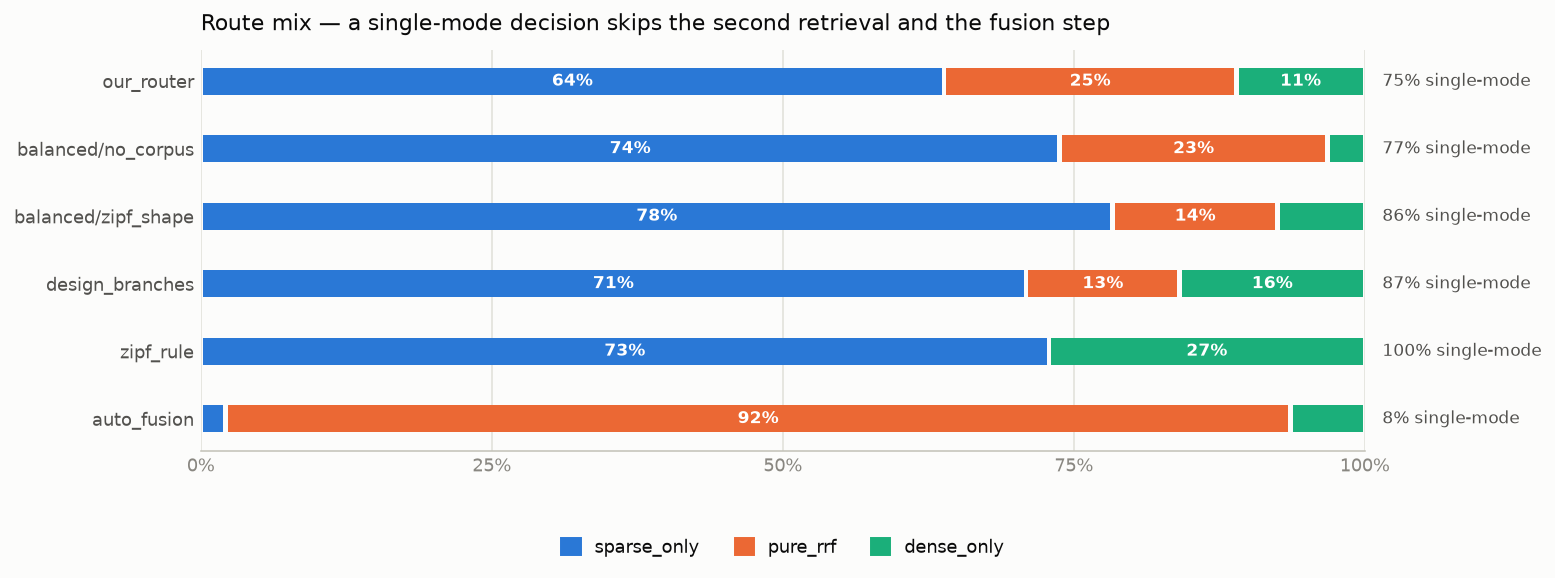

In [12]:
# 5e — where each arm sends traffic. Part-to-whole -> stacked bars, 2px surface gaps
# doing the separating, and the single-mode share is the cost story (one retrieval leg, no fusion).
MIX_ROUTES = [("sparse_only", BLUE), ("pure_rrf", ORANGE), ("dense_only", AQUA)]
mix_arms = [a for a in ("our_router", "balanced/no_corpus", "balanced/zipf_shape",
                        "design_branches", "zipf_rule", "auto_fusion")
            if a in results]

fig, ax = plt.subplots(figsize=(11.2, 0.40 * len(mix_arms) + 1.9))
for arm_i, arm in enumerate(mix_arms):
    share = results[arm]["route"].value_counts(normalize=True)
    left = 0.0
    for route, colour in MIX_ROUTES:
        w = float(share.get(route, 0.0))
        if w <= 0:
            continue
        ax.barh(arm_i, w - 0.004, left=left + 0.002, height=0.40, color=colour, zorder=3)  # 2px-equivalent gap
        if w >= 0.10:                                  # label only where the text fits inside
            ax.text(left + w / 2, arm_i, f"{w:.0%}", ha="center", va="center",
                    color="#ffffff", fontsize=8.5, fontweight="bold")
        left += w
    single = 1 - float(share.get("pure_rrf", 0.0))
    ax.text(1.015, arm_i, f"{single:.0%} single-mode", va="center", fontsize=8.5, color=INK2)

ax.set_yticks(range(len(mix_arms)), mix_arms, fontsize=9)
ax.set_xlim(0, 1.0)
ax.set_xticks([0, .25, .5, .75, 1], ["0%", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
bare(ax)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for _, c in MIX_ROUTES],
          labels=[r for r, _ in MIX_ROUTES], loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=3, frameon=False, fontsize=9, handlelength=1.1, handleheight=1.1)
ax.set_title("Route mix — a single-mode decision skips the second retrieval and the fusion step",
             loc="left", fontsize=11.5, color=INK, pad=10)
fig.tight_layout()
plt.show()


## 5c · Paired significance (Wilcoxon signed-rank)

Every metric is per-query over the same query set, so each comparison is paired and the effect
lives only in the **discordant** queries (the ones where the two arms route differently).
Wilcoxon is the non-parametric paired test.

Comparisons are restricted to the queries **both** arms decided: `auto_fusion` runs on its cached
3,000, and reindexing it over the full lane would zero-fill the rest and compare it against
zeros rather than against itself. So read `n` per row. Several comparisons, so treat p < ~0.017
(Bonferroni) as safely significant rather than 0.05.


In [13]:
from scipy.stats import wilcoxon


def _shared(a: str, b: str) -> list[str]:
    """Queries BOTH arms decided. An arm on a partial cache (auto_fusion) would otherwise be
    reindexed to 0.0 on the rest, turning its comparison into a comparison against zeros."""
    have = set(results[a]["query_id"]) & set(results[b]["query_id"])
    return [q for q in sample_ids if q in have]


def _rel_vec(name: str, ids: list[str]) -> np.ndarray:
    return results[name].set_index("query_id").reindex(ids)["rel_at_1"].fillna(0.0).to_numpy()


def _ndcg_vec(route_of, ids: list[str]) -> np.ndarray:
    return np.array([ndcg_at_k(q, route_of(q)) for q in ids if route_of(q) is not None])


_pairs = [("our_router", "sparse_only"), ("our_router", "fixed_rrf"), ("our_router", "auto_fusion"),
          ("weighted_rrf", "sparse_only"), ("weighted_rrf", "our_router"),
          ("design_branches", "our_router"), ("design_branches", "balanced/no_corpus"),
          ("design_branches", "sparse_only"),
          ("balanced/no_corpus", "our_router"),
          ("balanced/zipf_shape", "balanced/no_corpus"),
          ("balanced/zipf_shape", "our_router"), ("balanced/zipf_shape", "sparse_only")]
_rows = []
for a, b in _pairs:
    if a not in results or b not in results:
        continue
    _ids = _shared(a, b)
    for metric, va, vb in (("relevance@1", _rel_vec(a, _ids), _rel_vec(b, _ids)),
                           ("ndcg@10", _ndcg_vec(arms[a], _ids), _ndcg_vec(arms[b], _ids))):
        nz = int((va != vb).sum())
        pval = wilcoxon(va, vb).pvalue if nz else float("nan")
        _rows.append({"A": a, "B": b, "metric": metric, "n": len(va),
                      "A_mean": va.mean(), "B_mean": vb.mean(), "delta": va.mean() - vb.mean(),
                      "discordant": nz, "wilcoxon_p": pval, "sig@.017": pval < 0.017})

display(pd.DataFrame(_rows).round({"A_mean": 3, "B_mean": 3, "delta": 3, "wilcoxon_p": 4}))
print("negative delta vs sparse_only = the constant still beats the router (expected).")


,A,B,metric,n,A_mean,B_mean,delta,discordant,wilcoxon_p,sig@.017
0,our_router,sparse_only,relevance@1,11795,0.585,0.616,-0.031,699,0.0000,True
1,our_router,sparse_only,ndcg@10,11795,0.249,0.264,-0.015,2506,0.0000,True
2,our_router,fixed_rrf,relevance@1,11795,0.585,0.552,0.033,1238,0.0000,True
3,our_router,fixed_rrf,ndcg@10,11795,0.249,0.237,0.012,5437,0.0000,True
4,our_router,auto_fusion,relevance@1,3000,0.599,0.550,0.049,319,0.0047,True
5,our_router,auto_fusion,ndcg@10,3000,0.252,0.233,0.018,1362,0.0000,True
6,weighted_rrf,sparse_only,relevance@1,11795,0.544,0.616,-0.072,2503,0.0000,True
7,weighted_rrf,sparse_only,ndcg@10,11795,0.214,0.264,-0.051,7287,0.0000,True
8,weighted_rrf,our_router,relevance@1,11795,0.544,0.585,-0.041,2142,0.0001,True
9,weighted_rrf,our_router,ndcg@10,11795,0.214,0.249,-0.036,6802,0.0000,True


negative delta vs sparse_only = the constant still beats the router (expected).


### 5f · Paired deltas — signed, with significance

The same numbers as the table above, read as "who beats whom and by how much". Zero means *no
better than the comparator*; bars are driven only by the discordant queries, so a small bar over
a large discordant count is a real but thin effect.


/var/folders/pq/gsx7ryn905s1bypf32zs4k980000gn/T/ipykernel_46585/736358645.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=8.5)


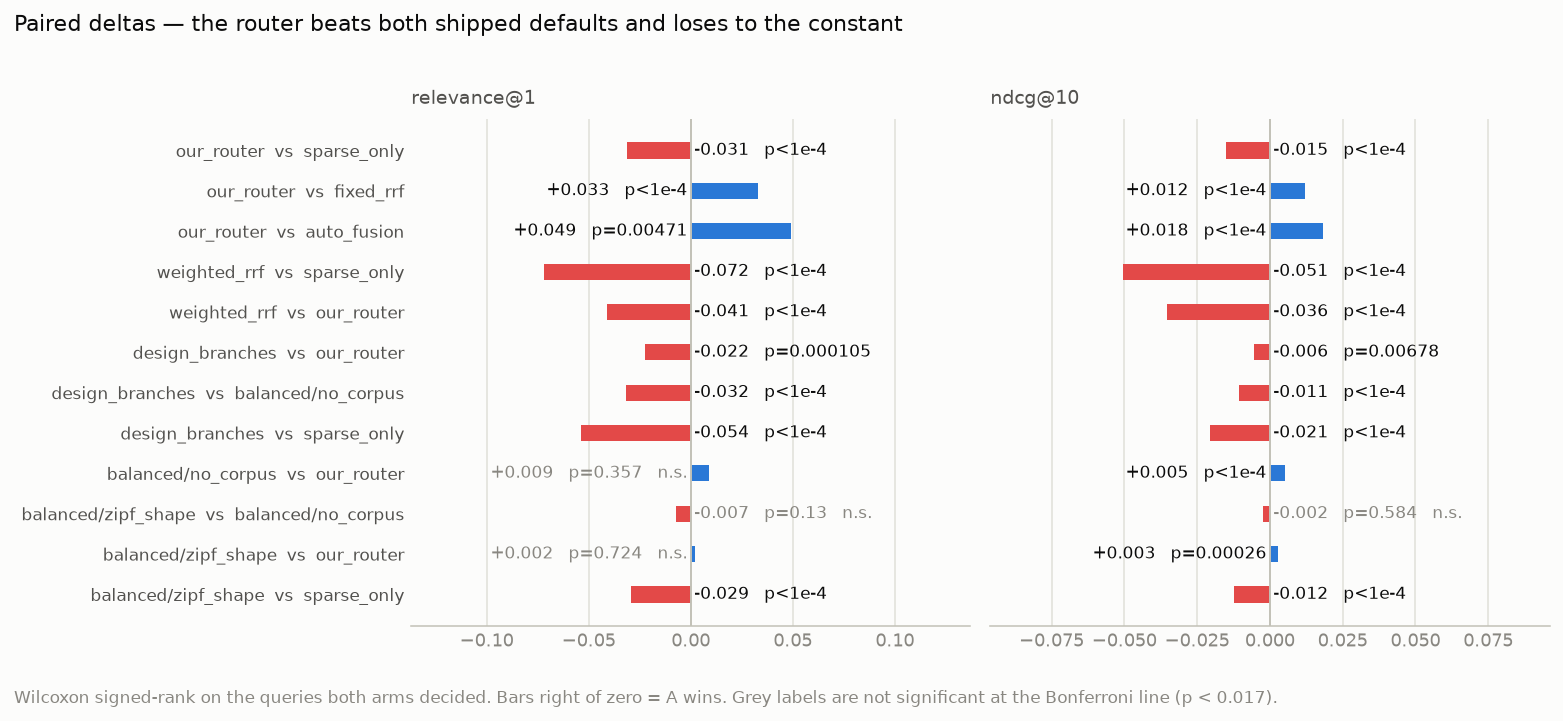

In [14]:
# 5f — the paired result, as the reader should read it: signed delta against each
# comparator, 0 = "no better than". Diverging blue/red (warm/cool poles, neutral zero),
# p-values direct-labelled; only the discordant queries can move a bar.
paired = pd.DataFrame(_rows)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), sharey=True)
for ax, metric in zip(axes, ("relevance@1", "ndcg@10")):
    sub = paired[paired["metric"] == metric].copy()
    sub["label"] = sub["A"] + "  vs  " + sub["B"]
    sub["sig"] = sub["wilcoxon_p"] < 0.017          # named, not itertuples' positional alias
    sub = sub.iloc[::-1]
    ax.barh(sub["label"], sub["delta"], height=0.40,
            color=[BLUE if d > 0 else RED for d in sub["delta"]], zorder=3)
    ax.axvline(0, color=BASELINE, lw=1.0, zorder=4)
    span = max(sub["delta"].abs()) * 1.9
    for y, r in enumerate(sub.itertuples()):
        p = "p<1e-4" if r.wilcoxon_p < 1e-4 else f"p={r.wilcoxon_p:.3g}"
        tag = f"{r.delta:+.3f}   {p}" + ("" if r.sig else "   n.s.")
        # anchor the label just past zero, on the empty side: a long bar can then never
        # push its label into the y-axis labels (measure-first rule, without measuring text)
        ax.text(0.012 * span if r.delta < 0 else -0.012 * span, y, tag, va="center",
                ha="left" if r.delta < 0 else "right", fontsize=8.5,
                color=INK if r.sig else MUTED)
    ax.set_xlim(-span, span)
    ax.set_title(metric, loc="left", color=INK2, fontsize=10, pad=8)
    bare(ax)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=8.5)
fig.suptitle("Paired deltas — the router beats both shipped defaults and loses to the constant",
             x=0.008, ha="left", fontsize=11.5, color=INK, y=1.02)
fig.text(0.008, -0.05, "Wilcoxon signed-rank on the queries both arms decided. Bars right of zero = A wins. "
                       "Grey labels are not significant at the Bonferroni line (p < 0.017).",
         fontsize=8.5, color=MUTED)
fig.tight_layout()
plt.show()


### 5g · Cost vs quality — is the cheap route Pareto-optimal?

`relevance@1` against the retrieval legs each arm actually fetches (a hedged query pays for
both). Up and to the left wins. `auto_fusion` additionally pays one LLM call per query, which
this axis does not charge it for.


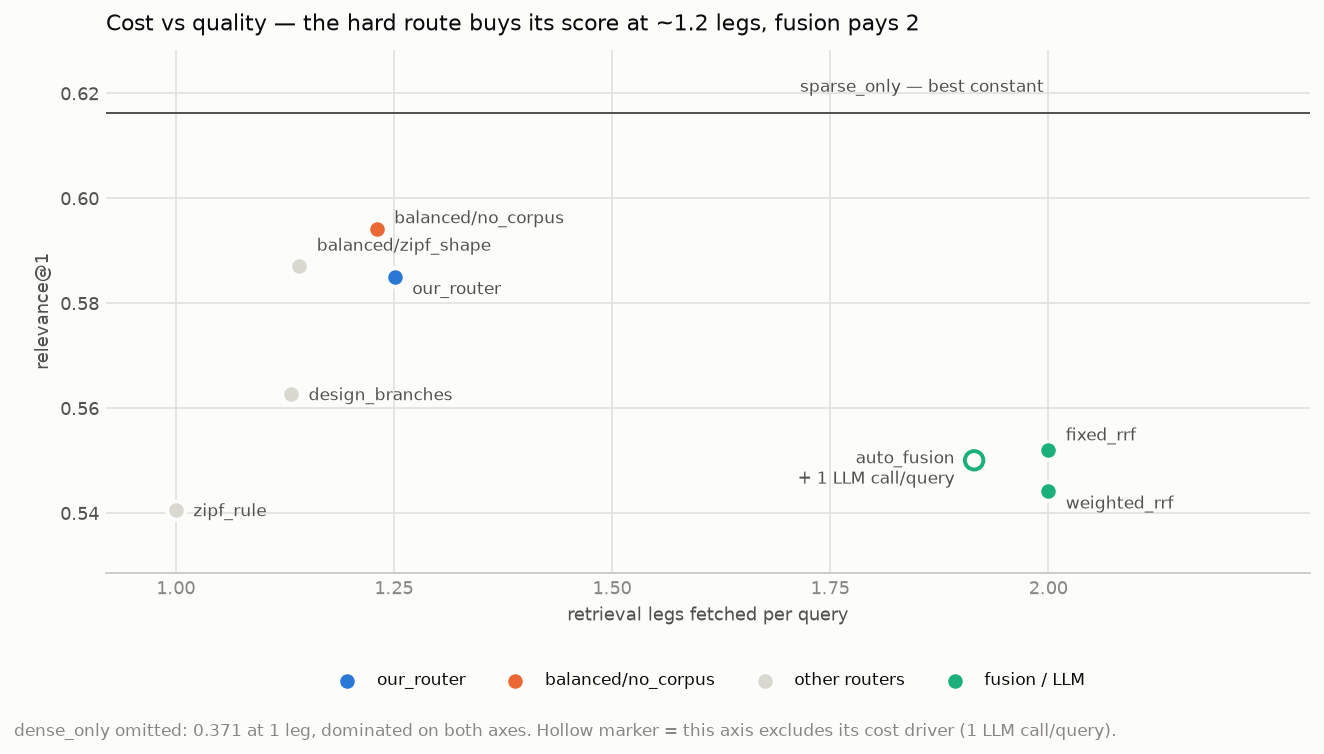

In [15]:
# 5g — the Pareto claim, drawn. x = retrieval legs actually fetched per query (a hedged
# query pays for both), y = relevance@1. The cheap hard route is up-and-to-the-left of fusion.
def legs_per_query(arm: str) -> float:
    if arm in ("fixed_rrf", "weighted_rrf"):
        return 2.0
    if arm in ("dense_only", "sparse_only"):
        return 1.0
    r = results[arm]["route"]
    return float((r == "pure_rrf").mean() + 1.0)      # hedged queries fetch dense AND sparse


# Same two subjects as fig_standings keep their colours here; the rest of "routers" recede to
# gray so blue/orange mean one thing across both figures instead of "router" vs "fusion".
GROUPS = {"our_router": (BLUE, ["our_router"]),
          "balanced/no_corpus": (ORANGE, ["balanced/no_corpus"]),
          "other routers": (DIM, ["design_branches", "balanced/zipf_shape", "zipf_rule"]),
          "fusion / LLM": (AQUA, ["fixed_rrf", "weighted_rrf", "auto_fusion"])}
rel = summary.set_index("arm")["relevance@1"]
CONSTANT = "sparse_only"        # reference line only, not a plotted point — same value as the
                                 # "best constant" line in fig_standings, drawn once, not twice
# dense_only is left off: at 0.371 it is dominated on both axes and stretched the y-range
# over an empty middle. Hand-placed label offsets — the x=2.0 cluster collides otherwise.
NUDGE = {"our_router": (9, -9), "balanced/no_corpus": (9, 3), "design_branches": (9, -3),
         "balanced/zipf_shape": (9, 8), "zipf_rule": (9, -3), "fixed_rrf": (9, 5),
         "weighted_rrf": (9, -9), "auto_fusion": (-10, -12)}

fig, ax = plt.subplots(figsize=(9.4, 5.2))
for label, (colour, members) in GROUPS.items():
    pts = [(legs_per_query(a), rel[a], a) for a in members if a in results]
    filled = [(x, y) for x, y, a in pts if a != "auto_fusion"]
    hollow = [(x, y) for x, y, a in pts if a == "auto_fusion"]
    if filled:
        ax.scatter(*zip(*filled), s=90, color=colour, edgecolors=SURFACE, linewidths=2,
                   zorder=4, label=label)   # 2px surface ring
    if hollow:      # auto_fusion only: position is real, but it omits the LLM-call cost
        ax.scatter(*zip(*hollow), s=90, facecolors="none", edgecolors=colour, linewidths=2,
                   zorder=4, label=label if not filled else None)
    for x, y, a in pts:
        note = a + ("\n+ 1 LLM call/query" if a == "auto_fusion" else "")
        dx, dy = NUDGE[a]
        ax.annotate(note, (x, y), textcoords="offset points", xytext=(dx, dy), fontsize=8.5,
                    color=INK2, zorder=5, ha="right" if dx < 0 else "left")
ax.axhline(rel[CONSTANT], color=INK2, lw=1.0, zorder=2)
ax.text(1.995, rel[CONSTANT] + 0.004, f"{CONSTANT} — best constant", ha="right", fontsize=8.5, color=INK2)
ax.set_xlabel("retrieval legs fetched per query")
ax.set_ylabel("relevance@1")
ax.set_xlim(0.92, 2.30)
ax.set_xticks([1.0, 1.25, 1.5, 1.75, 2.0])
bare(ax)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_ylim(min(rel[a] for a in ("zipf_rule", "weighted_rrf")) - 0.012, rel[CONSTANT] + 0.012)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, frameon=False, fontsize=8.5)
ax.set_title("Cost vs quality — the hard route buys its score at ~1.2 legs, fusion pays 2",
             loc="left", fontsize=11.5, color=INK, pad=10)
fig.text(0.0, -0.02, "dense_only omitted: 0.371 at 1 leg, dominated on both axes. Hollow marker = "
                     "this axis excludes its cost driver (1 LLM call/query).",
         fontsize=8.5, color=MUTED)
fig.tight_layout()
plt.show()


### 5h · Cost at scale — three arms, projected over query volume

The same per-query rates from §5g (`legs_per_query`, plus `auto_fusion`'s fixed 1 LLM call),
scaled to 100 / 1,000 / 50,000 / 100,000 queries. Only the three arms that matter for this
question: the free heuristic (`zipf_rule`), our deployed MLP (`our_router`), and the paid LLM
classifier (`auto_fusion`) — every other arm in this notebook shares one of these three cost
profiles (a router = free classify + retrieval legs; a fixed strategy = 1 or 2 legs, no
classify call at all).

`our_router`'s cost/quality profile is close to `balanced/no_corpus`'s (1.25 vs 1.23 legs/query) —
swap the arm below if you want that one instead. **"Coverage" here reads as `relevance@1`**;
say so if you meant route coverage (§5e) or something else.


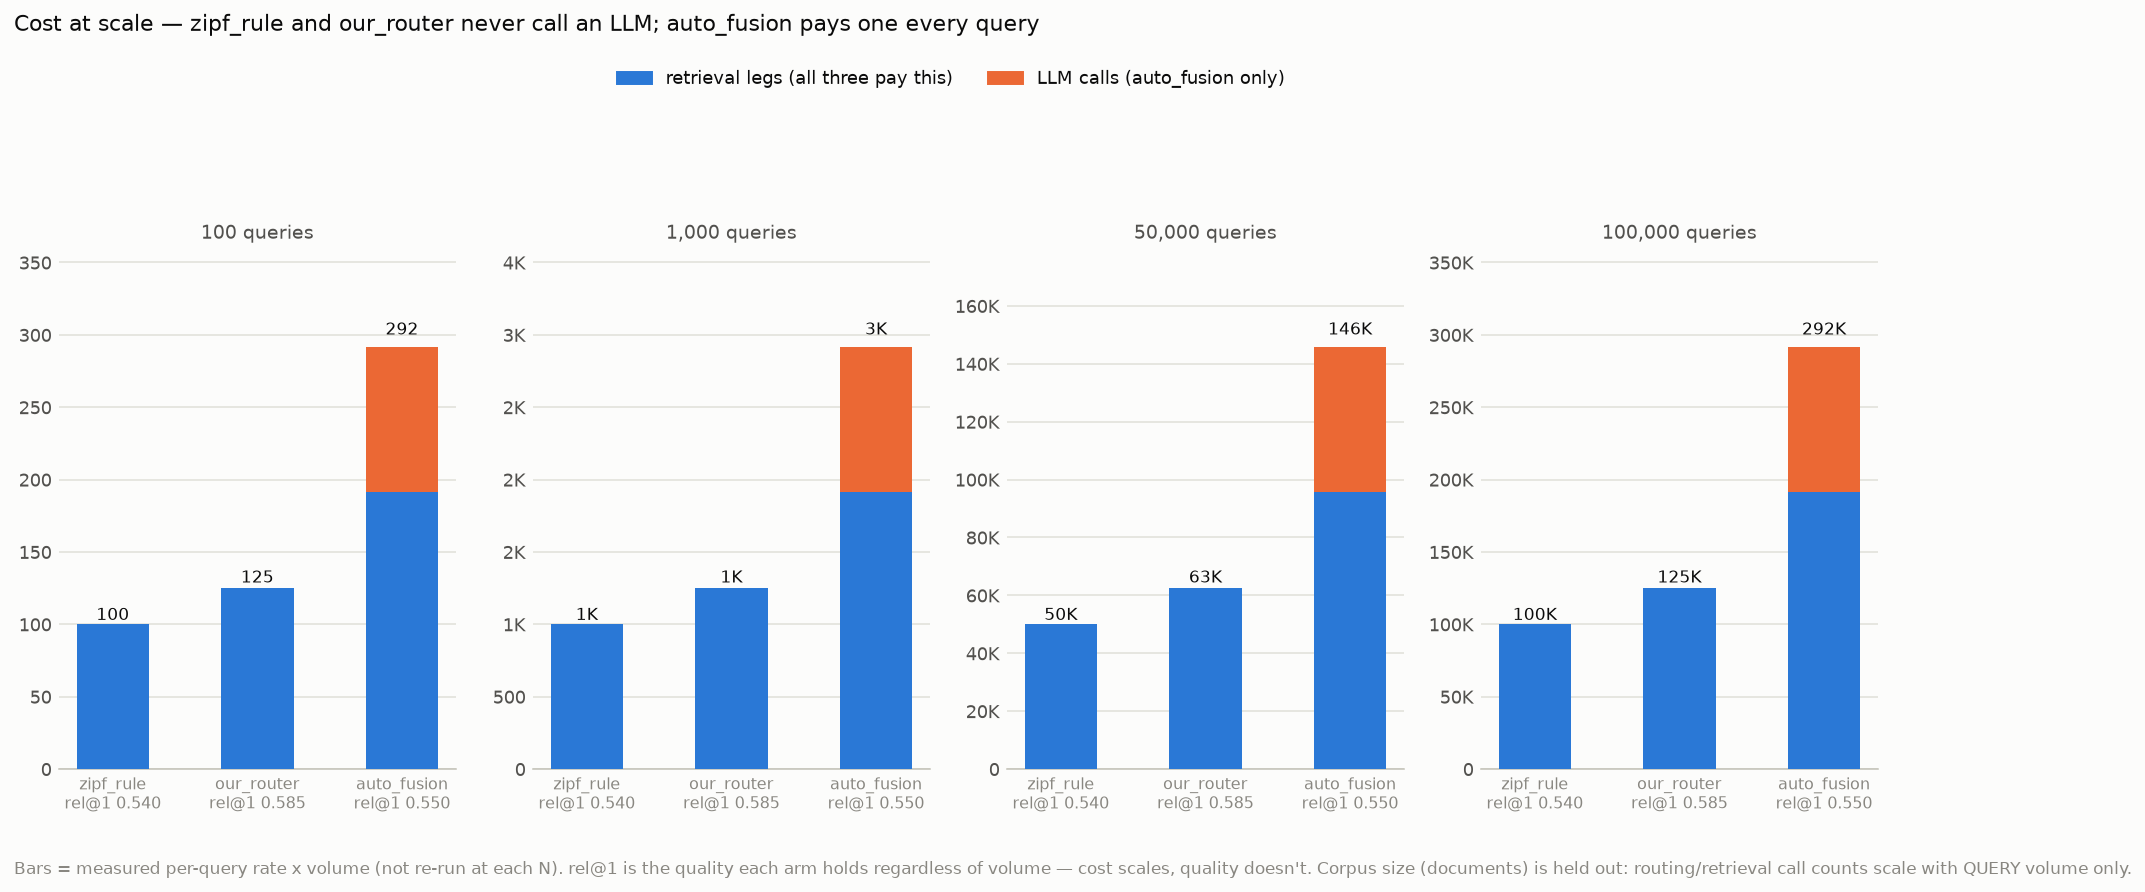

In [16]:
# 5h — cost at scale: the same per-query rates already measured, projected across query
# volume. Three arms only: the free heuristic, our deployed MLP, and the paid LLM classifier —
# every other config in this notebook shares one of these three cost profiles.
VOLUMES = [100, 1_000, 50_000, 100_000]
SCALE_ARMS = ["zipf_rule", "our_router", "auto_fusion"]

llm_rate = {"zipf_rule": 0.0, "our_router": 0.0, "auto_fusion": 1.0}   # LLM calls / query
leg_rate = {a: legs_per_query(a) for a in SCALE_ARMS}                  # retrieval legs / query,
                                                                        # reuses fig_pareto's measured rate
scale_df = pd.DataFrame([
    {"arm": a, "n": n, "llm_calls": n * llm_rate[a], "retrieval_legs": n * leg_rate[a]}
    for n in VOLUMES for a in SCALE_ARMS
])


def _fmt(n):
    return f"{n/1000:.0f}K" if n >= 1000 else f"{n:.0f}"


fig, axes = plt.subplots(1, len(VOLUMES), figsize=(13.6, 4.8), sharey=False)
for ax, n in zip(axes, VOLUMES):
    sub = scale_df[scale_df["n"] == n].set_index("arm").loc[SCALE_ARMS]
    x = np.arange(len(SCALE_ARMS))
    ax.bar(x, sub["retrieval_legs"], width=0.5, color=BLUE, zorder=3)
    ax.bar(x, sub["llm_calls"], width=0.5, bottom=sub["retrieval_legs"], color=ORANGE, zorder=3)
    totals = sub["retrieval_legs"] + sub["llm_calls"]
    for xi, a in zip(x, SCALE_ARMS):
        ax.text(xi, totals[a] * 1.03, _fmt(totals[a]), ha="center", fontsize=8.5, color=INK)
    ax.set_xticks(x, [f"{a}\nrel@1 {rel[a]:.3f}" for a in SCALE_ARMS], fontsize=8)
    ax.set_ylim(0, totals.max() * 1.22)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: _fmt(v)))
    ax.set_title(f"{n:,} queries", fontsize=10, color=INK2, loc="center", pad=8)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)

fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)],
           labels=["retrieval legs (all three pay this)", "LLM calls (auto_fusion only)"],
           loc="upper center", bbox_to_anchor=(0.5, 1.16), ncol=2, frameon=False, fontsize=9)
fig.suptitle("Cost at scale — zipf_rule and our_router never call an LLM; auto_fusion pays one every query",
             x=0.008, ha="left", fontsize=11.5, color=INK, y=1.22)
fig.text(0.008, -0.06,
         "Bars = measured per-query rate x volume (not re-run at each N). rel@1 is the quality each "
         "arm holds regardless of volume — cost scales, quality doesn't. Corpus size (documents) is "
         "held out: routing/retrieval call counts scale with QUERY volume only.",
         fontsize=8.5, color=MUTED)
fig.tight_layout()
plt.show()


## Conclusions

11,795 out-of-lane Home Depot product queries — the full lane. Every arm shares one index + RRF
and one hedge delta, so rows differ only by the routing decision. Metrics are paired per-query
(Wilcoxon signed-rank). `our_router` is the arm the local service had loaded:
`zipf_shape_nocorpus` at thresholds `[0.30, 0.85]`.

**What holds — significant on BOTH relevance@1 and NDCG@10:**
- The **free** encoder-router beats both shipped defaults — production hybrid RRF (rel@1
  **+0.033**, p<1e-4; NDCG@10 +0.012, p<1e-4) and the **LLM** fusion classifier (rel@1
  **+0.049**, p=0.005; NDCG@10 +0.018, p<1e-4) — at **zero per-query cost**, with **75%** of
  queries routed single-mode, skipping the second retrieval and the fusion step.
- Using the router's probabilities as **soft fusion weights** (weighted RRF) is significantly
  **worse** than the hard single-route decision (rel@1 −0.041, p=1e-4; NDCG@10 −0.036, p<1e-4),
  and it retrieves both legs, so it costs like full hybrid.
  → The cheap **hard route is Pareto-optimal** (§5g): it earns its score at ~1.25 retrieval legs
  per query, while weighted fusion pays 2 legs to do worse.

**The honest ceiling:**
- A per-collection **BM25 constant still beats the router** (rel@1 −0.031, p<1e-4; NDCG@10
  −0.015, p<1e-4). The router is a **strong zero-config default / cold-start prior**, not the
  per-collection optimum.
- Even perfect routing tops out at **oracle hit@1 0.305** — ~70% of queries are unwinnable by
  ANY route, so the larger lever is **retrieval quality**, not routing.

**Arm choice is lane-bound — the result to carry forward:**
- `design_branches` topped the held-out-lane panel in the volume probe and is significantly
  **worse** here (rel@1 −0.022, p=1e-4; −0.054 against the constant). `balanced/no_corpus` is the
  best non-constant arm on this corpus (0.594 / 0.254). Two lanes, two winners — which is the
  whole reason this out-of-lane bakeoff exists rather than trusting the in-lane readout.

**Caveats (state these when presenting):**
- Dense is `all-MiniLM` (bge has no cloud-inference endpoint) — a fair dense index could shift
  the picture and is the cleanup to close first.
- The dense threshold `0.85` was hand-set by sweeping the cached 3,000 and is now measured on a
  superset of them, so it is partly in-sample. Tune on the 3,000, report on the 8,795 complement.
- Incomplete qrels (44% of the catalog rated) → absolute numbers are floors; the paired
  comparisons are on the measurable subset.
- `auto_fusion` is scored on 3,000 queries (its cached LLM scores), every other arm on 11,795.
- One collection (ecommerce). The router beats the baselines *here*; the whole point is that the
  winning route is collection-specific, so the direction does not generalize.

**One-line takeaway.** On unseen product search, a free encoder-router significantly beats both
the production hybrid and the production LLM classifier at top-1 and NDCG@10, and the cheap hard
route now beats soft weighted fusion outright — while a collection-tuned BM25 constant still
wins, so the router's role is a strong, retrieval-cost-saving default.


## 6 · Eye test — every system's decision + top-1 product for one query

Pick a query; see side-by-side what each arm decides and the actual rank-1 **product** it
returns: our_router (route + p_dense/p_sparse), auto_fusion (0-9 score, bucketed),
weighted_rrf (router-weighted fusion), and the fixed baselines. Retrieves live, so run it
one query (or a few) at a time.

In [17]:
import uuid


def _product(doc_id):
    if not doc_id:
        return "-"
    pid = str(uuid.uuid5(uuid.NAMESPACE_DNS, doc_id))
    pts = client.retrieve(COLLECTION, ids=[pid], with_payload=["title", "text"])
    if not pts:
        return "-"
    pl = pts[0].payload or {}
    return (pl.get("title") or pl.get("text") or "")[:80]


def compare_query(q):
    r = requests.post(CLASSIFY_URL, json={"queries": [q], "delta": HEDGE_DELTA}, timeout=60).json()["results"][0]
    pdv, psv, r_route = r["p_dense"], r["p_sparse"], r["route"]
    try:
        af = requests.post(AUTOFUSION_URL, json={"text": q}, headers=headers, timeout=45).json()
        af_route = bucket(af["score"])
    except requests.RequestException:       # service down -> drop the row, keep the eye test
        af = af_route = None
    ranks = {name: list(strat.rank(q)) for name, strat in strategies.items()}
    ws = {}
    for i, d in enumerate(ranks["dense_only"]):
        ws[d] = ws.get(d, 0.0) + pdv / (60 + i + 1)
    for i, d in enumerate(ranks["sparse_only"]):
        ws[d] = ws.get(d, 0.0) + psv / (60 + i + 1)
    wrrf = [d for d, _ in sorted(ws.items(), key=lambda kv: kv[1], reverse=True)]

    def top(lst):
        return lst[0] if lst else None

    plan = {
        "our_router": (r_route, top(ranks[r_route])),
        **({"auto_fusion": (f"score {af['score']} -> {af_route}", top(ranks[af_route]))} if af else {}),
        "weighted_rrf": ("weighted fusion", top(wrrf)),
        "fixed_rrf": ("pure_rrf", top(ranks["pure_rrf"])),
        "sparse_only": ("sparse_only", top(ranks["sparse_only"])),
        "dense_only": ("dense_only", top(ranks["dense_only"])),
    }
    print(f"Q: {q!r}")
    print(f"   router p_dense={pdv:.2f} p_sparse={psv:.2f} -> {r_route}   |   "
          f"auto_fusion -> {af_route or 'service down'}")
    return pd.DataFrame([{"arm": a, "decision": dec, "top1_doc": doc, "product": _product(doc)}
                         for a, (dec, doc) in plan.items()])


pd.set_option("display.max_colwidth", 82)
display(compare_query("GE Profile refrigerator PSS26MSWSS"))


Q: 'GE Profile refrigerator PSS26MSWSS'
   router p_dense=0.63 p_sparse=0.59 -> pure_rrf   |   auto_fusion -> service down


,arm,decision,top1_doc,product
0,our_router,pure_rrf,198959,"GE Profile 24.6 cu. ft. Side by Side Refrigerator in Stainless Steel, Counter De"
1,weighted_rrf,weighted fusion,198959,"GE Profile 24.6 cu. ft. Side by Side Refrigerator in Stainless Steel, Counter De"
2,fixed_rrf,pure_rrf,198959,"GE Profile 24.6 cu. ft. Side by Side Refrigerator in Stainless Steel, Counter De"
3,sparse_only,sparse_only,150106,GE Profile 29.75 in. 20 cu. ft. French Door Refrigerator in Stainless Steel
4,dense_only,dense_only,198959,"GE Profile 24.6 cu. ft. Side by Side Refrigerator in Stainless Steel, Counter De"


In [18]:
display(compare_query("comfortable patio chair for a small balcony"))

Q: 'comfortable patio chair for a small balcony'
   router p_dense=0.81 p_sparse=0.54 -> sparse_only   |   auto_fusion -> service down


,arm,decision,top1_doc,product
0,our_router,sparse_only,171860,Hampton Bay Bloomfield Woven Balcony Height Patio Dining Chair with Moss Cushion
1,weighted_rrf,weighted fusion,193134,Coleman Patio Sling Chair
2,fixed_rrf,pure_rrf,212469,BitBuddie Drill Bit for Stone/Marble/Concrete
3,sparse_only,sparse_only,171860,Hampton Bay Bloomfield Woven Balcony Height Patio Dining Chair with Moss Cushion
4,dense_only,dense_only,212469,BitBuddie Drill Bit for Stone/Marble/Concrete


In [19]:
display(compare_query("blue red carpet"))

Q: 'blue red carpet'
   router p_dense=0.54 p_sparse=0.42 -> sparse_only   |   auto_fusion -> service down


,arm,decision,top1_doc,product
0,our_router,sparse_only,155124,Natco Heavy Traffic Assorted Solid Color 6 ft. x 8 ft. Carpet Remnant
1,weighted_rrf,weighted fusion,155124,Natco Heavy Traffic Assorted Solid Color 6 ft. x 8 ft. Carpet Remnant
2,fixed_rrf,pure_rrf,155124,Natco Heavy Traffic Assorted Solid Color 6 ft. x 8 ft. Carpet Remnant
3,sparse_only,sparse_only,155124,Natco Heavy Traffic Assorted Solid Color 6 ft. x 8 ft. Carpet Remnant
4,dense_only,dense_only,136479,Shaw Amusing Carpet 100% BCF Anso (Color Options)


In [20]:
display(compare_query("T-shirt with tiger"))

Q: 'T-shirt with tiger'
   router p_dense=0.63 p_sparse=0.65 -> pure_rrf   |   auto_fusion -> service down


,arm,decision,top1_doc,product
0,our_router,pure_rrf,152815,Auburn University 23 in. x 43 in. Yard Sign with Stake
1,weighted_rrf,weighted fusion,152815,Auburn University 23 in. x 43 in. Yard Sign with Stake
2,fixed_rrf,pure_rrf,152815,Auburn University 23 in. x 43 in. Yard Sign with Stake
3,sparse_only,sparse_only,126949,Safavieh Newbury Tiger Stripe Aluminum Frame Wicker Patio Chair (2-Pack)
4,dense_only,dense_only,152815,Auburn University 23 in. x 43 in. Yard Sign with Stake


### 6b · The opposite of the eye test — where hybrid loses to a clean single-mode win

Every query where `sparse_only` or `dense_only` genuinely hits (rel ≥ 2.0) and `pure_rrf`'s
rank-1 is a rated document that scores lower — the fusion dilutes an otherwise clean win. Split
from the much larger population where hybrid's top-1 simply was never rated (looks identical
in the raw score, but isn't a real miss — see the incomplete-qrels caveat above).

In [21]:
# 6b — the opposite of the eye test: queries where a single mode WINS BIG and hybrid loses.
# Split genuine losses (rrf's top-1 IS rated, just low/wrong) from the incomplete-qrels
# confound (rrf's top-1 was simply never rated — looks like a miss, isn't necessarily one).
titles = pd.read_parquet(CACHE / "corpus.parquet").astype({"doc_id": str}).set_index("doc_id")["title"]


def _local_title(doc_id):
    return titles.get(doc_id, "-")[:70] if doc_id else "-"


_rows = []
for qid in sample_ids:
    routes = rankings.get(qid, {})
    rec = {"query_id": qid}
    for route in ("sparse_only", "dense_only", "pure_rrf"):
        docs = routes.get(route, [])
        doc = docs[0] if docs else None
        rec[f"{route}_doc"] = doc
        rec[f"{route}_rated"] = doc in rated.get(qid, {}) if doc else False
        rec[route] = rated.get(qid, {}).get(doc, 0.0) if doc else 0.0
    _rows.append(rec)
gap = pd.DataFrame(_rows)
gap["best_single"] = gap[["sparse_only", "dense_only"]].max(axis=1)
gap["winner"] = np.where(gap["sparse_only"] >= gap["dense_only"], "sparse_only", "dense_only")
gap["winner_doc"] = np.where(gap["winner"] == "sparse_only", gap["sparse_only_doc"], gap["dense_only_doc"])

hybrid_loses = (gap["best_single"] >= REL_THRESHOLD) & (gap["pure_rrf"] < REL_THRESHOLD)
genuine = gap[hybrid_loses & gap["pure_rrf_rated"]].sort_values(
    ["best_single", "pure_rrf"], ascending=[False, True])
confound = gap[hybrid_loses & ~gap["pure_rrf_rated"]]

print(f"{len(genuine):,} queries: a single mode hits AND hybrid's top-1 IS rated, just low/wrong "
      "(a genuine loss to fusion)")
print(f"{len(confound):,} more LOOK like losses but hybrid's top-1 was never rated at all "
      "(the incomplete-qrels caveat — not counted as a real miss)")

top = genuine.head(8).copy()
top["query"] = top["query_id"].map(sample_text)
top["winning_product"] = top["winner_doc"].map(_local_title)
top["rrf_product"] = top["pure_rrf_doc"].map(_local_title)
display(top[["query", "winner", "best_single", "winning_product", "pure_rrf", "rrf_product"]]
        .rename(columns={"best_single": "winner_rel", "pure_rrf": "rrf_rel"}))


20 queries: a single mode hits AND hybrid's top-1 IS rated, just low/wrong (a genuine loss to fusion)
1,125 more LOOK like losses but hybrid's top-1 was never rated at all (the incomplete-qrels caveat — not counted as a real miss)


,query,winner,winner_rel,winning_product,rrf_rel,rrf_product
3586,mr coffee,sparse_only,3.00,Mr. Coffee 10-Cup Thermal Coffeemaker in Black,1.33,Mr. Coffee 20 oz. Cafe Frappe Maker
3529,4 in in line duct,sparse_only,3.00,Inductor 4 in. In-Line Duct Fan,1.67,24 in. x 8 in. x 4 ft. Half Section Rectangular Duct
6828,gold class car wash,sparse_only,3.00,Meguiar&#39;s 24 oz. Gold Class Premium Quik Detailer,1.67,Meguiar&#39;s 64 oz. Deep Crystal Car Wash
11166,drip per stakes,dense_only,2.67,Deep Drip 24 in. Watering Stake,1.00,Orbit 1/4 in. Loop Stake (10-Pack)
11480,bird stops,sparse_only,2.67,Heath Bird Stop Orange Ceramic Wild Bird Feeder,1.00,Heath Bird Stop Blue Ceramic Wild Bird Feeder
1965,flat screen tv brace,dense_only,2.67,QuakeHOLD! Universal Flat-Screen Television Safety Strap,1.67,QuakeHOLD! 40 in. Flat-Screen TV Strap
3337,anderson screens ax4,sparse_only,2.67,Prime-Line Anderson Side Adjustable Screen Door Tension Spring,1.67,Andersen 31-31/32 in. x 20-5/32 in. Awning Insect Screen
6426,mr clean magic eraser brown,sparse_only,2.67,Mr. Clean Outdoor Pro Magic Erasers (7-Pack),1.67,Mr. Clean Magic Eraser Extra Power Sponges (Case of 30)


### 6c · Presentation example — the clearest single-query NDCG loss

One concrete, non-confounded case for a slide: `pure_rrf`'s low-ranked docs here are genuinely
rated (not the incomplete-qrels artifact from §6b), so this is fusion actually burying real
matches, not a labeling gap.

In [22]:
# 6c — the headline NDCG@10 example: "wood garage door". Not cherry-picked from the confound —
# hybrid's low docs here ARE rated, so this is a genuine loss, not an unrated-doc artifact.
HEADLINE_QUERY = "wood garage door"
_qid = queries.index[queries["text"] == HEADLINE_QUERY][0]
print(f"query: {HEADLINE_QUERY!r}  |  rated docs: {len(rated.get(_qid, {}))}")
print(f"sparse_only ndcg@10 = {ndcg_at_k(_qid, 'sparse_only'):.3f}   "
      f"pure_rrf ndcg@10 = {ndcg_at_k(_qid, 'pure_rrf'):.3f}   "
      f"(dense_only ndcg@10 = {ndcg_at_k(_qid, 'dense_only'):.3f})")

_rows = []
for rank in range(10):
    row = {"rank": rank + 1}
    for route in ("sparse_only", "pure_rrf"):
        docs = rankings.get(_qid, {}).get(route, [])
        d = docs[rank] if rank < len(docs) else None
        g = rated.get(_qid, {}).get(d) if d else None
        label = _local_title(d) if d else "-"
        row[f"{route}_product"] = f"[{g:.0f}] {label}" if g is not None else label
    _rows.append(row)
headline = pd.DataFrame(_rows).rename(
    columns={"sparse_only_product": "sparse_only (winner)", "pure_rrf_product": "pure_rrf (hybrid)"})
pd.set_option("display.max_colwidth", 62)
display(headline)
print("\n[N] prefix = relevance grade. Six graded products cluster at ranks 4-10 for sparse; "
      "fusion keeps only one, at rank 9 — the rest are pushed out by dense_only's unrated results.")


query: 'wood garage door'  |  rated docs: 7
sparse_only ndcg@10 = 0.631   pure_rrf ndcg@10 = 0.061   (dense_only ndcg@10 = 0.000)


,rank,sparse_only (winner),pure_rrf (hybrid)
0,1,IDEAL Security 140 lb. Garage Door Springs with Safety Cab...,IDEAL Security 140 lb. Garage Door Springs with Safety Cab...
1,2,,
2,3,Owens Corning 9 ft. Wood Door Bottom Seal (6-Piece per Car...,
3,4,[2] Clopay 4 in. x 3 in. Wood Garage Door Sample in Hemloc...,
4,5,[3] Clopay 4 in. x 3 in. Wood Garage Door Sample in Merant...,Clopay Gallery Collection 16 ft. x 7 ft. 6.5 R-Value Insul...
5,6,[3] Clopay 4 in. x 3 in. Wood Garage Door Sample in Luan w...,Owens Corning 9 ft. Wood Door Bottom Seal (6-Piece per Car...
6,7,[3] Clopay 4 in. x 3 in. Wood Garage Door Sample in Luan w...,Steves &amp; Sons Rustic 2-Panel Plank Prefinished Oak Woo...
7,8,[2] Clopay 4 in. x 3 in. Wood Garage Door Sample in Luan w...,
8,9,[3] Clopay 4 in. x 3 in. Wood Garage Door Sample in Light ...,[2] Clopay 4 in. x 3 in. Wood Garage Door Sample in Hemloc...
9,10,[2] Clopay 4 in. x 3 in. Wood Garage Door Sample in Light ...,



[N] prefix = relevance grade. Six graded products cluster at ranks 4-10 for sparse; fusion keeps only one, at rank 9 — the rest are pushed out by dense_only's unrated results.


## 7 · Rated-candidate mode — clean-signal companion (future work)

Full-corpus hit@1 / NDCG@10 undercount because only ~44% of the catalog is rated (an unrated
top-1 scores as a miss). The clean-signal companion re-ranks only each query's rated products
(a `doc_id`-filtered `query_points` reusing each strategy's query embed), so rank-1 is always
judgeable. It measures re-ranking among candidates rather than real retrieval — a
methods-appendix check, not the headline. And because the undercount hits every arm roughly
equally, the PAIRED comparisons above are already robust to it. Deferred deliberately: it does
not change the relative claims; the higher-value cleanup is a **bge dense index** (removing the
all-MiniLM confound), not this.